# Functional-cluster HGA (NMF)

Same figure types as `vizpub/fig2_legacy.ipynb`, but groups are the
canonical NMF **k=3** functional clusters instead of AIC / PIC:

**Candidate panels (screen before main figure):**

- **-1a. NMF basis waveforms** — canonical H from concat NMF (`H_by_phase.csv`)
- **-1b. Loading / dominance QC** — assignment confidence by cluster
- **-1c. Cluster membership summary** — n electrodes / subjects per cluster
- **-1d. Cluster × AIC/PIC contingency** — anatomy vs functional label
- **-1e. Model selection curves** — recon / energy / silhouette / stability (k=1–3)
- **-1f. Concatenated basis timeline** — H stitched across phases
- **-1g. Loading pairwise scatter + dominance strip**
- **-1h. Cluster × AIC/PIC stacked bars**
- **-1i. NMF waveform summary mean±SEM** — from `waveform_summary.csv`

**Main figure panels:**

0. **Parcel composition** — each cluster vs Hammersmith's 6 insula subdivisions
   (bar + pie)
1. **Time traces** — mean ± CI across the NMF electrode union
2. **Heatmap** — three rows (k=3 clusters); rows = union members; non-significant
   timepoints blanked via `mask`
3. **Spatial** — one panel per phase; points = union; color = cluster;
   size ∝ phase-window mean HGA

Specificity-weighted Gaussian density (soft loadings, not hard argmax) is a
separate notebook: [`functional_hga_specificity.ipynb`](functional_hga_specificity.ipynb).

**Electrode rule (hybrid):** membership follows the NMF sig-union assignment
table; significance only controls display (heatmap NaNs, spatial size), not
who belongs to a cluster.

Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).


In [1]:
%matplotlib inline

import os
import sys
import warnings
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pyvista as pv
import seaborn as sns
import xarray as xr
from IPython.display import display
from matplotlib.patches import Patch
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import (
    RESULTS_ROOT,
    hga_results_dir,
    nmf_assignments_path,
    nmf_results_dir,
)

os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
pv.OFF_SCREEN = True
mne.viz.set_3d_backend('notebook')


Using notebook 3d backend.


In [2]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontsize = 7
fontdict = dict(fontsize=fontsize)

red = '#A9373B'   # sustained_ramping
gold = '#C4A35A'  # intermediate
blue = '#2369BD'  # sensory_transient

# Canonical published NMF: concat crop_postonset k=3
CLUSTERS = ['sustained_ramping', 'intermediate', 'sensory_transient']
CLUSTER_COLORS = {
    'sustained_ramping': red,
    'intermediate': gold,
    'sensory_transient': blue,
}
CLUSTER_LABELS = {
    'sustained_ramping': 'sustained / ramping',
    'intermediate': 'intermediate',
    'sensory_transient': 'sensory / transient',
}
CLUSTER_CMAPS = {
    name: sns.light_palette(color, as_cmap=True)
    for name, color in CLUSTER_COLORS.items()
}

# Match NMF discovery tasks (Repeat + sound only when subsetting)
TASKS = [
    'PhonemeSequence',
    'LexicalDelay',
    'PictureNaming',
    'LexicalNoDelay',
    'SentenceRep',
]
PHASES = ['stimulus', 'delay', 'go', 'response']
DESCRIPTION = 'Repeat'
MODALITY = 'sound'
EXCLUDE_SUBJECTS = {'D0121'}

# Spatial: mean HGA in this post-onset window within each phase
SPATIAL_TIME = {
    'stimulus': (0.0, 0.5),
    'delay': (0.0, 0.5),
    'go': (0.0, 0.5),
    'response': (0, 0.5),
}

NMF_DIR = nmf_results_dir()
NMF_ASSIGNMENTS = nmf_assignments_path()
recon_dir = '/cwork/ns458/ECoG_Recon/'
from src.paths import img_dir
IMG_DIR = img_dir('functional_hga/')
SPATIAL_PHASES_OUT = IMG_DIR / 'functional_hga_spatial_phases.svg'

# Gaussian surface density (3-color RGB blend); tune these freely

DENSITY_WEIGHT_BY_HGA = True  # weight each electrode by window-mean HGA
SPATIAL_DENSITY_OUT = IMG_DIR / 'functional_hga_spatial_phases_density.svg'


## Load NMF assignments + packaged HGA

Keep only channels present in `channel_assignments.csv` (NMF union ∩ AIC/PIC
filters used at discovery time).


In [3]:
assignments = pd.read_csv(NMF_ASSIGNMENTS)
assign_map = assignments.set_index('channel')['functional_cluster']
keep_channels = set(assignments['channel'])

hga_paths = []
for task in TASKS:
    hga_paths.extend(
        BIDSPath(
            root=str(hga_results_dir(task)),
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

frames = []
for path in tqdm(hga_paths, desc='load HGA'):
    df = pd.read_csv(path)
    if 'channel' not in df.columns:
        continue
    df = df[df['channel'].isin(keep_channels)]
    if not df.empty:
        frames.append(df)

if not frames:
    raise FileNotFoundError(
        f'No HGA rows for NMF channels under results/hga/ for tasks={TASKS}'
    )

HGAs = pd.concat(frames, ignore_index=True)
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].astype(str).str.lower()
HGAs['functional_cluster'] = HGAs['channel'].map(assign_map)

subset = HGAs[
    (HGAs.description == DESCRIPTION)
    & (HGAs.modality == MODALITY)
    & HGAs['functional_cluster'].isin(CLUSTERS)
    & ~HGAs['subject'].isin(EXCLUDE_SUBJECTS)
].copy()
subset['cluster_label'] = subset['functional_cluster'].map(CLUSTER_LABELS)

print('assignments:', NMF_ASSIGNMENTS)
print(subset.groupby('functional_cluster')['channel'].nunique())
print('phases:', sorted(subset.phase.unique()))
print('tasks in subset:', sorted(subset.task.unique()) if 'task' in subset.columns else 'n/a')
display(subset.head())


load HGA:   0%|          | 0/1855 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3262931898.py:18: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3262931898.py:18: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3262931898.py:18: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3262931898.py:18: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3262931898.py:18: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


assignments: /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/channel_assignments.csv
Series([], Name: channel, dtype: int64)
phases: []
tasks in subset: []


,time,channel,value,mask,subject,description,task,phase,modality,label,...,x2_template,y2_template,z2_template,contact_1,contact_2,contact_1_label,contact_2_label,mix,functional_cluster,cluster_label


## Figure-1 candidates (before parcel composition)

Quick QC panels to decide what stays on the main figure. Run after the
load cell above; outputs go to `IMG_DIR`.


### -1a. NMF basis waveforms


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3898253826.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3898253826.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3898253826.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3898253826.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


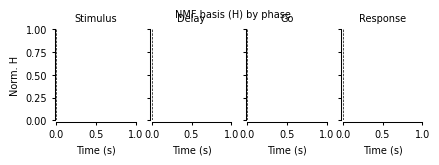

In [4]:
H_by_phase = pd.read_csv(NMF_DIR / 'H_by_phase.csv')
H_by_phase = H_by_phase[H_by_phase['functional_cluster'].isin(CLUSTERS)].copy()
H_by_phase['cluster_label'] = H_by_phase['functional_cluster'].map(CLUSTER_LABELS)
H_by_phase['phase'] = pd.Categorical(H_by_phase['phase'], categories=PHASES, ordered=True)

hue_order = [CLUSTER_LABELS[c] for c in CLUSTERS]
palette = [CLUSTER_COLORS[c] for c in CLUSTERS]

fig, axes = plt.subplots(
    nrows=1, ncols=len(PHASES), figsize=(3 * len(PHASES) * cm, 3 * cm),
)
plt.subplots_adjust(wspace=0.2)

for ax, phase in zip(axes, PHASES):
    sub = H_by_phase[H_by_phase['phase'] == phase]
    legend = ax is axes[-2]
    sns.lineplot(
        data=sub,
        x='time',
        y='normalized_H',
        hue='cluster_label',
        hue_order=hue_order,
        ax=ax,
        palette=palette,
        legend=legend,
        lw=1.2,
    )
    ax.set_title(phase.capitalize(), fontsize=fontsize)
    ax.set_xlabel('Time (s)', fontsize=fontsize)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if ax is axes[-1] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=fontsize)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    if ax is not axes[0]:
        ax.set_yticklabels([])
    ax.set_ylabel('Norm. H' if ax is axes[0] else '', fontsize=fontsize)

fig.suptitle('NMF basis (H) by phase', fontsize=fontsize, y=1.05)
fig.savefig(IMG_DIR / 'functional_hga_nmf_basis.svg', dpi=300, bbox_inches='tight')
plt.show()


### -1b. Loading / dominance QC


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_240890/3420662148.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


ValueError: No objects to concatenate

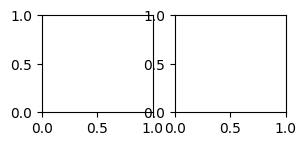

In [5]:
LOADING_COLS = {
    'sustained_ramping': 'loading_sustained_ramping',
    'intermediate': 'loading_intermediate',
    'sensory_transient': 'loading_sensory_transient',
}
assign_qc = assignments[assignments['functional_cluster'].isin(CLUSTERS)].copy()
assign_qc['cluster_label'] = assign_qc['functional_cluster'].map(CLUSTER_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(8 * cm, 3.2 * cm))

sns.histplot(
    data=assign_qc,
    x='dominance',
    hue='cluster_label',
    hue_order=[CLUSTER_LABELS[c] for c in CLUSTERS],
    palette=[CLUSTER_COLORS[c] for c in CLUSTERS],
    multiple='stack',
    bins=20,
    ax=axes[0],
    legend=False,
)
axes[0].set_xlabel('Dominance (assigned / sum loadings)', fontsize=fontsize)
axes[0].set_ylabel('Count', fontsize=fontsize)
axes[0].set_title('Dominance', fontsize=fontsize)

mean_load = (
    assign_qc.groupby('functional_cluster', observed=True)[list(LOADING_COLS.values())]
    .mean()
    .reindex(CLUSTERS)
    .rename(columns={v: CLUSTER_LABELS[k] for k, v in LOADING_COLS.items()})
)
mean_load.plot(
    kind='bar',
    ax=axes[1],
    color=[CLUSTER_COLORS[c] for c in CLUSTERS],
    edgecolor='white',
    linewidth=0.5,
    rot=0,
)
axes[1].set_xlabel('Assigned cluster', fontsize=fontsize)
axes[1].set_ylabel('Mean loading', fontsize=fontsize)
axes[1].set_title('Mean loadings by assignment', fontsize=fontsize)
axes[1].legend(title='', fontsize=fontsize, loc='upper right')

for ax in axes:
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)

fig.savefig(IMG_DIR / 'functional_hga_loadings_qc.svg', dpi=300, bbox_inches='tight')
plt.show()


### -1c. Cluster membership summary


In [ ]:
import json

manifest = json.loads((NMF_DIR / 'nmf_manifest.json').read_text())
membership = (
    assignments[assignments['functional_cluster'].isin(CLUSTERS)]
    .groupby('functional_cluster', observed=True)
    .agg(
        n_electrodes=('channel', 'nunique'),
        n_subjects=('subject', 'nunique'),
    )
    .reindex(CLUSTERS)
    .rename(index=CLUSTER_LABELS)
)
display(membership)
print(
    f"Total assigned: {len(assignments)} electrodes, "
    f"{assignments['subject'].nunique()} subjects"
)
print(f"NMF manifest condition: {manifest.get('condition')} | k={manifest.get('k')}")


,n_electrodes,n_subjects
functional_cluster,,
sustained / ramping,100,42
intermediate,145,58
sensory / transient,36,19


Total assigned: 281 electrodes, 65 subjects
NMF manifest condition: Repeat | k=3


### -1e. Model selection curves (supports k=3)

From `model_selection_metrics.csv` (concat post-onset). Grid currently covers
**k=1–3 only** — no k≥4 elbow in this file. Dashed line = selected k=3.


,k,reconstruction_error,explained_energy,silhouette_cosine,stability_ari,min_cluster_n,cluster_counts,converged_runs,n_init
0,1,11.421364,0.535774,NaN,NaN,281,281,0,20
1,2,9.933057,0.648877,0.292469,1.0,136,145;136,20,20
2,3,9.187029,0.699639,0.277681,1.0,42,146;93;42,20,20


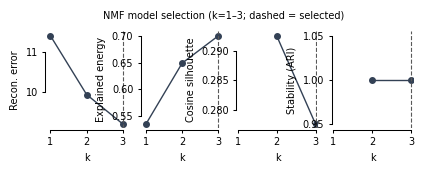

Note: metrics stop at k=3; silhouette is slightly higher for k=2 than k=3.


In [ ]:
metrics = pd.read_csv(NMF_DIR / 'model_selection_metrics.csv')
display(metrics)
selected_k = 3

fig, axes = plt.subplots(1, 4, figsize=(12 * cm, 3.2 * cm))
panels = [
    ('reconstruction_error', 'Recon. error'),
    ('explained_energy', 'Explained energy'),
    ('silhouette_cosine', 'Cosine silhouette'),
    ('stability_ari', 'Stability (ARI)'),
]
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(metrics['k'], metrics[col], 'o-', color='#334155', lw=1, markersize=4)
    ax.axvline(selected_k, color='0.35', linestyle='--', linewidth=0.8)
    ax.set_xlabel('k', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xticks(metrics['k'].tolist())
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)

fig.suptitle('NMF model selection (k=1–3; dashed = selected)', fontsize=fontsize, y=1.05)
fig.savefig(IMG_DIR / 'functional_hga_model_selection.svg', dpi=300, bbox_inches='tight')
plt.show()
print('Note: metrics stop at k=3; silhouette is slightly higher for k=2 than k=3.')


## 0. Hammersmith parcel composition

For each NMF functional cluster, show how channels distribute across the
**six Hammersmith insula subdivisions** (hemisphere suffix stripped from
`label`):

1. anterior pole  
2. anterior short gyrus  
3. middle short gyrus  
4. posterior short gyrus  
5. anterior long gyrus  
6. posterior long gyrus  

Empirical predominance: **ant. short → sustained**;
**ant./post. long → sensory**; others more mixed.

Parcel labels come from Hammers `*_coord.csv` (main checkout preferred).

Figures:
- count bars (cluster × parcel)
- **Option C** — per-parcel pies (sustained vs sensory mix)
- **Option E** — within-cluster pies with home parcels spotlighted


NMF channels with valid Hammers parcel: 280 / 281
Global P(sustained) = 0.35


,parcel,n,n_sustained,n_intermediate,n_sensory,P(sustained|parcel),enrich_vs_global,fisher_p,role
parcel_short,,,,,,,,,
ant. pole,insula anterior pole,39,23,12,4,0.589744,0.236172,1.800903e-03,mixed
ant. short,insula anterior short gyrus,63,42,21,0,0.666667,0.313095,1.046062e-08,sustained-dom
mid. short,insula middle short gyrus,30,4,26,0,0.133333,-0.220238,7.852372e-03,mixed
post. short,insula posterior short gyrus,48,10,34,4,0.208333,-0.145238,2.084920e-02,mixed
ant. long,insula anterior long gyrus,48,3,37,8,0.062500,-0.291071,6.661140e-07,sensory-dom
post. long,insula posterior long gyrus,52,17,15,20,0.326923,-0.026648,7.485888e-01,sensory-dom


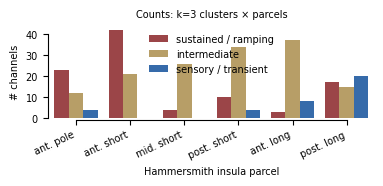

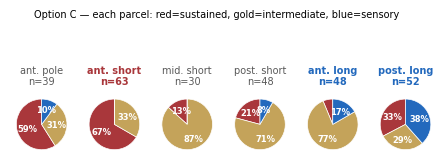

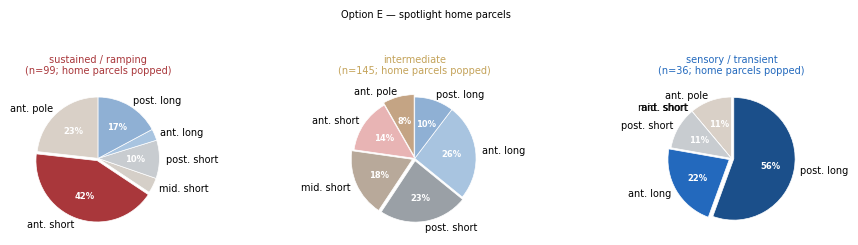

In [ ]:
from scipy.stats import fisher_exact

HAMMERS_INSULA_PARCELS = [
    'insula anterior pole',
    'insula anterior short gyrus',
    'insula middle short gyrus',
    'insula posterior short gyrus',
    'insula anterior long gyrus',
    'insula posterior long gyrus',
]
PARCEL_SHORT = {
    'insula anterior pole': 'ant. pole',
    'insula anterior short gyrus': 'ant. short',
    'insula middle short gyrus': 'mid. short',
    'insula posterior short gyrus': 'post. short',
    'insula anterior long gyrus': 'ant. long',
    'insula posterior long gyrus': 'post. long',
}

# Predominance-aware colors
PARCEL_COLOR = {
    'insula anterior pole': '#C4A484',
    'insula anterior short gyrus': red,
    'insula middle short gyrus': '#B8A99A',
    'insula posterior short gyrus': '#9AA0A6',
    'insula anterior long gyrus': blue,
    'insula posterior long gyrus': '#1B4F8A',
}
PARCEL_ROLE = {
    'insula anterior pole': 'mixed',
    'insula anterior short gyrus': 'sustained-dom',
    'insula middle short gyrus': 'mixed',
    'insula posterior short gyrus': 'mixed',
    'insula anterior long gyrus': 'sensory-dom',
    'insula posterior long gyrus': 'sensory-dom',
}
HOME = {
    'sustained_ramping': {'insula anterior short gyrus'},
    'intermediate': {
        'insula anterior pole',
        'insula middle short gyrus',
        'insula posterior short gyrus',
    },
    'sensory_transient': {
        'insula anterior long gyrus', 'insula posterior long gyrus',
    },
}
MUTED = {
    'insula anterior pole': '#D9D0C7',
    'insula anterior short gyrus': '#E8B4B4',
    'insula middle short gyrus': '#D5CFC8',
    'insula posterior short gyrus': '#C8CCD0',
    'insula anterior long gyrus': '#A8C4E0',
    'insula posterior long gyrus': '#8FB0D4',
}


def _strip_hemi_label(label) -> str:
    s = str(label).strip()
    if s.endswith(' L') or s.endswith(' R'):
        return s[:-2]
    return s


def _style_pie_autotexts(autotexts):
    for t in autotexts:
        t.set_color('white')
        t.set_fontweight('bold')
        t.set_fontsize(6)


# Hammersmith parcel labels from packaged HGA (Repeat + sound)
label_src = subset.dropna(subset=['channel', 'label']).copy()
label_src = label_src[~label_src['label'].astype(str).isin(['0', 'nan', ''])]
label_by_ch = (
    label_src.groupby('channel', as_index=True)['label']
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
)

parcel_df = assignments[['channel', 'functional_cluster']].copy()
parcel_df = parcel_df[parcel_df['functional_cluster'].isin(CLUSTERS)].copy()
parcel_df['label'] = parcel_df['channel'].map(label_by_ch)
parcel_df['insula_parcel'] = parcel_df['label'].map(
    lambda x: _strip_hemi_label(x) if pd.notna(x) else pd.NA
)
n_assigned = int(assignments['functional_cluster'].isin(CLUSTERS).sum())
parcel_df = parcel_df[parcel_df['insula_parcel'].isin(HAMMERS_INSULA_PARCELS)].copy()
parcel_df['cluster_label'] = parcel_df['functional_cluster'].map(CLUSTER_LABELS)
parcel_df['parcel_short'] = parcel_df['insula_parcel'].map(PARCEL_SHORT)

print(f'NMF channels with valid Hammers parcel: {len(parcel_df)} / {n_assigned}')

counts = (
    parcel_df.groupby(['functional_cluster', 'insula_parcel'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)
counts['cluster_label'] = counts['functional_cluster'].map(CLUSTER_LABELS)
counts['parcel_short'] = counts['insula_parcel'].map(PARCEL_SHORT)
counts['insula_parcel'] = pd.Categorical(
    counts['insula_parcel'], categories=HAMMERS_INSULA_PARCELS, ordered=True,
)

ct = (
    counts.pivot_table(
        index='insula_parcel', columns='functional_cluster', values='n', fill_value=0,
    )
    .reindex(index=HAMMERS_INSULA_PARCELS, columns=CLUSTERS)
    .fillna(0)
    .astype(int)
)
base_sust = parcel_df['functional_cluster'].eq('sustained_ramping').mean()
rows = []
for p in HAMMERS_INSULA_PARCELS:
    n_s = int(ct.loc[p, 'sustained_ramping'])
    n_i = int(ct.loc[p, 'intermediate'])
    n_e = int(ct.loc[p, 'sensory_transient'])
    n = n_s + n_i + n_e
    fs = n_s / n if n else np.nan
    # Enrichment: sustained vs all other clusters in this parcel
    a_, b_ = n_s, n_i + n_e
    c_ = int(ct['sustained_ramping'].sum() - n_s)
    d_ = int(
        ct['intermediate'].sum()
        + ct['sensory_transient'].sum()
        - (n_i + n_e)
    )
    _, pval = fisher_exact([[a_, b_], [c_, d_]], alternative='two-sided')
    rows.append({
        'parcel': p,
        'parcel_short': PARCEL_SHORT[p],
        'n': n,
        'n_sustained': n_s,
        'n_intermediate': n_i,
        'n_sensory': n_e,
        'P(sustained|parcel)': fs,
        'enrich_vs_global': fs - base_sust,
        'fisher_p': pval,
        'role': PARCEL_ROLE[p],
    })
pred_df = pd.DataFrame(rows)
print(f'Global P(sustained) = {base_sust:.2f}')
display(pred_df.set_index('parcel_short'))

# --- Count bars ---
fig, ax = plt.subplots(figsize=(10 * cm, 5 * cm))
sns.barplot(
    data=counts,
    x='parcel_short',
    y='n',
    hue='cluster_label',
    hue_order=[CLUSTER_LABELS[c] for c in CLUSTERS],
    palette=[CLUSTER_COLORS[c] for c in CLUSTERS],
    order=[PARCEL_SHORT[p] for p in HAMMERS_INSULA_PARCELS],
    ax=ax,
)
ax.set_xlabel('Hammersmith insula parcel', fontsize=fontsize)
ax.set_ylabel('# channels', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.legend(title='', fontsize=fontsize, frameon=False)
sns.despine(ax=ax, offset=1, trim=True)
ax.set_title('Counts: k=3 clusters × parcels', fontsize=fontsize)
plt.xticks(rotation=25, ha='right')
fig.tight_layout()
fig.savefig(IMG_DIR / 'functional_hga_parcel_bars.svg', dpi=300, bbox_inches='tight')
plt.show()

# --- Option C: per-parcel pies (3-cluster mix) ---
fig = plt.figure(figsize=(14 * cm, 5 * cm))
gs = fig.add_gridspec(1, len(HAMMERS_INSULA_PARCELS), wspace=0.15)
for idx, p in enumerate(HAMMERS_INSULA_PARCELS):
    ax = fig.add_subplot(gs[idx])
    sizes = [int(ct.loc[p, c]) for c in CLUSTERS]
    if sum(sizes) == 0:
        ax.axis('off')
        continue
    _, _, autotexts = ax.pie(
        sizes,
        labels=None,
        colors=[CLUSTER_COLORS[c] for c in CLUSTERS],
        autopct=lambda pct: f'{pct:.0f}%' if pct >= 8 else '',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )
    _style_pie_autotexts(autotexts)
    role = PARCEL_ROLE[p]
    title_color = (
        red if role == 'sustained-dom' else blue if role == 'sensory-dom' else '0.35'
    )
    ax.set_title(
        f'{PARCEL_SHORT[p]}' + chr(10) + f'n={sum(sizes)}',
        fontsize=fontsize,
        color=title_color,
        fontweight='bold' if role != 'mixed' else 'normal',
    )
fig.suptitle(
    'Option C — each parcel: red=sustained, gold=intermediate, blue=sensory',
    fontsize=fontsize,
    y=1.08,
)
fig.savefig(IMG_DIR / 'functional_hga_parcel_pies_optC.svg', dpi=300, bbox_inches='tight')
plt.show()

# --- Option E: spotlight home parcels ---
fig, axes = plt.subplots(1, len(CLUSTERS), figsize=(8 * len(CLUSTERS) * cm, 6 * cm))
if len(CLUSTERS) == 1:
    axes = [axes]
for ax, cluster in zip(axes, CLUSTERS):
    sub = counts[counts['functional_cluster'] == cluster].set_index('insula_parcel')
    sizes = [int(sub['n'].get(p, 0)) for p in HAMMERS_INSULA_PARCELS]
    total = sum(sizes)
    colors = []
    explode = []
    for p in HAMMERS_INSULA_PARCELS:
        if p in HOME[cluster]:
            colors.append(PARCEL_COLOR[p])
            explode.append(0.04)
        else:
            colors.append(MUTED[p])
            explode.append(0.0)
    _, _, autotexts = ax.pie(
        sizes,
        labels=[PARCEL_SHORT[p] for p in HAMMERS_INSULA_PARCELS],
        colors=colors,
        explode=explode,
        autopct=lambda pct: f'{pct:.0f}%' if pct >= 5 else '',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )
    _style_pie_autotexts(autotexts)
    ax.set_title(
        f'{CLUSTER_LABELS[cluster]}' + chr(10) + f'(n={total}; home parcels popped)',
        fontsize=fontsize,
        color=CLUSTER_COLORS[cluster],
    )
fig.suptitle('Option E — spotlight home parcels', fontsize=fontsize, y=1.02)
fig.tight_layout()
fig.savefig(IMG_DIR / 'functional_hga_parcel_pies_optE.svg', dpi=300, bbox_inches='tight')
plt.show()


## 1. Time traces

Subject-pooled mean HGA across the fixed NMF union, hue = functional cluster.


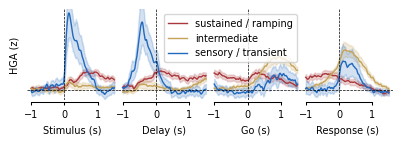

In [ ]:
hue_order = [CLUSTER_LABELS[c] for c in CLUSTERS]
palette = [CLUSTER_COLORS[c] for c in CLUSTERS]

fig, axes = plt.subplots(
    nrows=1, ncols=len(PHASES), figsize=(3 * len(PHASES) * cm, 3 * cm),
)
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, PHASES):
    legend = ax is axes[-2]
    sns.lineplot(
        data=subset[subset.phase == phase],
        x='time',
        y='value',
        hue='cluster_label',
        hue_order=hue_order,
        ax=ax,
        palette=palette,
        legend=legend,
        lw=1,
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)

    if ax is axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=fontsize)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 0.8)
    ax.set_ylabel('HGA (z)' if ax is axes[0] else '', fontsize=fontsize)

fig.savefig(IMG_DIR / 'functional_hga_traces.svg', dpi=300, bbox_inches='tight')
plt.show()

## 2. Heatmap (three k=3 cluster rows × four phases)

Rows within each cluster = NMF-union channels for that cluster. Values are
channel×time means; non-significant timepoints (`mask` False) set to NaN.
Channels sorted by first significant time within each phase.


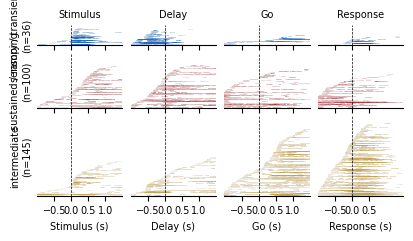

In [ ]:
def cluster_phase_channel_order(agg: pd.DataFrame, phase: str, cluster: str) -> list[str]:
    """Union channels for this cluster, sorted by first significant time in phase."""
    phase_data = agg[(agg.phase == phase) & (agg.functional_cluster == cluster)]
    channels = sorted(phase_data['channel'].unique())
    first_sig = []
    for ch in channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data.loc[ch_data['mask'], 'time'].to_numpy()
        first_sig.append((ch, float(sig_times.min()) if len(sig_times) else np.inf))
    return [ch for ch, _ in sorted(first_sig, key=lambda x: x[1])]


agg = (
    subset.groupby(['channel', 'time', 'phase', 'functional_cluster'], as_index=False)
    .agg(value=('value', 'mean'), mask=('mask', 'any'))
)
agg.loc[~agg['mask'], 'value'] = np.nan

# Heatmap row order: sensory → sustained → intermediate
HEATMAP_CLUSTERS = ['sensory_transient', 'sustained_ramping', 'intermediate']

# Row height ∝ n channels in each cluster (equal px per channel)
n_by_cluster = {
    c: int(subset.loc[subset.functional_cluster == c, 'channel'].nunique())
    for c in HEATMAP_CLUSTERS
}
height_ratios = [max(n_by_cluster[c], 1) for c in HEATMAP_CLUSTERS]

fig = plt.figure(
    figsize=(3 * len(PHASES) * cm, 0.02 * sum(height_ratios) * cm),
)
gs = fig.add_gridspec(
    nrows=len(HEATMAP_CLUSTERS),
    ncols=len(PHASES),
    height_ratios=height_ratios,
    hspace=0.15,
    wspace=0.1,
)
axes = np.empty((len(HEATMAP_CLUSTERS), len(PHASES)), dtype=object)
for i in range(len(HEATMAP_CLUSTERS)):
    for j in range(len(PHASES)):
        sharex = axes[0, j] if i > 0 else None
        axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

for i, cluster in enumerate(HEATMAP_CLUSTERS):
    cmap = CLUSTER_CMAPS[cluster]
    for j, phase in enumerate(PHASES):
        ax = axes[i, j]
        ordered = cluster_phase_channel_order(agg, phase, cluster)
        phase_data = agg[
            (agg.phase == phase)
            & (agg.functional_cluster == cluster)
            & agg.channel.isin(ordered)
        ]

        if not ordered:
            ax.text(
                0.5, 0.5, 'No channels',
                ha='center', va='center', transform=ax.transAxes, fontsize=fontsize,
            )
            ax.set_yticks([])
            continue

        pivot = (
            phase_data.pivot(index='channel', columns='time', values='value')
            .reindex(index=ordered)
        )
        da = xr.DataArray(
            pivot.to_numpy(dtype=float),
            coords={'channel': pivot.index, 'time': pivot.columns.astype(float)},
            dims=['channel', 'time'],
        )
        time_values = da.coords['time'].values.astype(float)
        step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
        time_edges = np.concatenate(
            ([time_values[0] - step / 2],
             time_values[:-1] + step / 2,
             [time_values[-1] + step / 2])
        )
        channel_edges = np.arange(len(ordered) + 1)
        T, C = np.meshgrid(time_edges, channel_edges)

        ax.pcolormesh(
            T, C, da.values, cmap=cmap, vmin=0, vmax=1,
            shading='auto', rasterized=True,
        )
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, len(ordered))
        ax.set_yticks([])
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)

        if i == len(HEATMAP_CLUSTERS) - 1:
            ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)
            ax.set_xticks([-0.5, 0, 0.5, 1.0] if phase != 'response' else [-0.5, 0, 0.5])
            ax.tick_params(labelsize=fontsize)
        else:
            ax.set_xlabel('')
            ax.set_xticks([])
            plt.setp(ax.get_xticklabels(), visible=False)

        if j == 0:
            ax.set_ylabel(
                f"{CLUSTER_LABELS[cluster]}\n(n={len(ordered)})",
                fontsize=fontsize,
            )
        if i == 0:
            ax.set_title(phase.capitalize(), fontsize=fontsize)

fig.savefig(IMG_DIR / 'functional_hga_heatmap.svg', dpi=300, bbox_inches='tight')
plt.show()

## 3. Spatial maps (all four phases)

Electrode spheres (size ∝ window-mean HGA, color = cluster × amplitude).  
Next cell: Gaussian surface-density RGB blend of the three clusters (tunable `DENSITY_BANDWIDTH` / `DENSITY_MAX_DISTANCE`).


Fixed NMF-union electrodes on the template pial surface. Color = functional
cluster; point size ∝ mean HGA in that phase's analysis window.


In [ ]:
def phase_spatial_table(frame: pd.DataFrame, phase: str) -> pd.DataFrame:
    t0, t1 = SPATIAL_TIME[phase]
    window = frame[
        (frame.phase == phase) & (frame.time > t0) & (frame.time < t1)
    ]
    spatial = (
        window.groupby('channel', as_index=False)
        .agg(
            HGA=('value', 'mean'),
            x=('x', 'first'),
            y=('y', 'first'),
            z=('z', 'first'),
            functional_cluster=('functional_cluster', 'first'),
            hemi=('hemi', 'first'),
            subject=('subject', 'first'),
            mask=('mask', 'any'),
        )
    )
    return spatial.dropna(subset=['x', 'y', 'z'])


spatial_by_phase = {phase: phase_spatial_table(subset, phase) for phase in PHASES}
for phase, table in spatial_by_phase.items():
    counts = ', '.join(
        f'{c}={int((table.functional_cluster == c).sum())}' for c in CLUSTERS
    )
    print(f'{phase}: n={len(table)} | {counts}')


stimulus: n=281 | sustained_ramping=100, intermediate=145, sensory_transient=36
delay: n=281 | sustained_ramping=100, intermediate=145, sensory_transient=36
go: n=281 | sustained_ramping=100, intermediate=145, sensory_transient=36
response: n=281 | sustained_ramping=100, intermediate=145, sensory_transient=36


In [ ]:
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152',
    parc='aparc.a2009s',
    surf_name='pial',
    hemi='both',
    subjects_dir=recon_dir,
)
insula_patterns = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if not vertices:
        return None
    return pial_coords[vertices].mean(axis=0)


lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)


def hga_to_size(hga, vmin, vmax, size_min=8, size_max=30):
    if vmax <= vmin:
        return np.full_like(hga, (size_min + size_max) / 2, dtype=float)
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)


def add_cluster_electrodes(brain, coords, hga_vals, clusters, tree, pial_coords, vmin, vmax):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    sizes = hga_to_size(hga_vals, vmin, vmax)
    for i in range(len(coords_proj)):
        cluster = clusters[i]
        cmap = CLUSTER_CMAPS[cluster]
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        color = cmap(norm(hga_vals[i]))
        cloud = pv.PolyData(coords_proj[i:i + 1])
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(sizes[i]),
            color=color,
            lighting=False,
        )


def render_phase_brains(spatial: pd.DataFrame):
    all_hga = spatial['HGA'].to_numpy(float)
    vmin, vmax = 0.0, float(np.percentile(all_hga, 90)) if len(all_hga) else 1.0

    lh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    rh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='rh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            brain = lh_brain if lab.hemi == 'lh' else rh_brain
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

    cord = spatial[['x', 'y', 'z']].to_numpy(float)
    hga_values = spatial['HGA'].to_numpy(float)
    cluster_values = spatial['functional_cluster'].to_numpy()
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    if mask_lh.any():
        add_cluster_electrodes(
            lh_brain, cord[mask_lh], hga_values[mask_lh], cluster_values[mask_lh],
            lh_tree, lh_pial_coords, vmin, vmax,
        )
    if mask_rh.any():
        add_cluster_electrodes(
            rh_brain, cord[mask_rh], hga_values[mask_rh], cluster_values[mask_rh],
            rh_tree, rh_pial_coords, vmin, vmax,
        )

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)
    lh_img = lh_brain.screenshot(mode='rgb')
    rh_img = rh_brain.screenshot(mode='rgb')
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img, vmin, vmax


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-08-03 10:05:11.550 ( 277.017s) [    7F1E83D27740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-08-03 10:05:11.606 ( 277.073s) [    7F1E83D27740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x201efd90): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases.svg


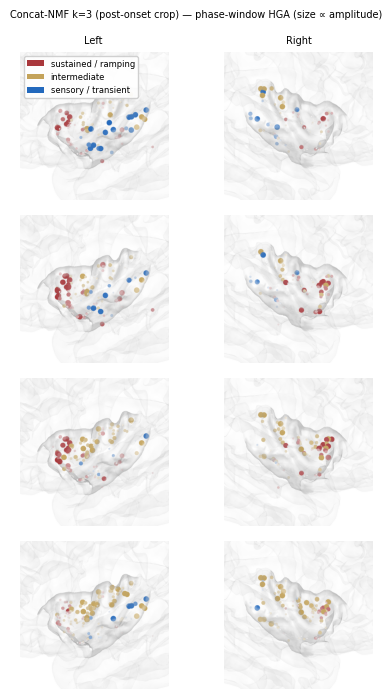

In [ ]:
fig, axes = plt.subplots(
    nrows=len(PHASES), ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(0.5, 0.5, f'No data ({phase})', ha='center', va='center')
            axes[row, col].axis('off')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lh_img, rh_img, vmin, vmax = render_phase_brains(spatial)

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title('Left' if row == 0 else '', fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title('Right' if row == 0 else '', fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])
    for c in CLUSTERS
]
axes[0, 0].legend(
    handles=legend_elements, loc='upper left',
    fontsize=fontsize - 1, framealpha=0.9,
)
fig.suptitle(
    'Concat-NMF k=3 (post-onset crop) — phase-window HGA (size ∝ amplitude)',
    fontsize=fontsize,
)
fig.tight_layout()
out = globals().get('SPATIAL_PHASES_OUT', IMG_DIR / 'functional_hga_spatial_phases.svg')
fig.savefig(out, dpi=300, bbox_inches='tight')
print(f'Wrote {out.resolve()}')
plt.show()


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-08-03 10:05:19.745 ( 285.212s) [    7F1E83D27740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2dc87f30): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases_density.svg


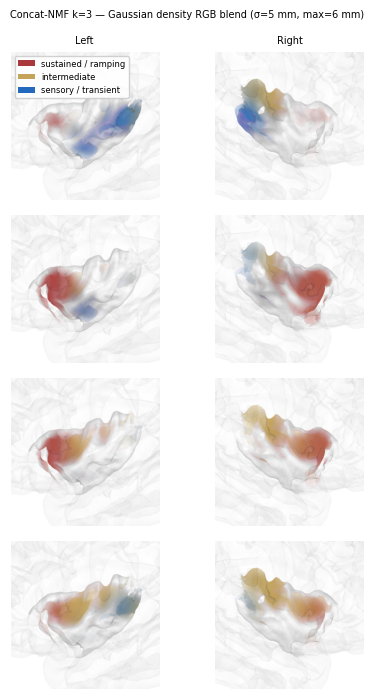

In [ ]:
DENSITY_BANDWIDTH = 5.0       # mm; Gaussian kernel σ
DENSITY_MAX_DISTANCE = 6.0    # mm; zero density beyond nearest electrode

# Gaussian density spatial maps: per-cluster surface KDE → RGB blend
from scipy.spatial.distance import cdist

CLUSTER_RGB = np.array(
    [mcolors.to_rgb(CLUSTER_COLORS[c]) for c in CLUSTERS],
    dtype=float,
)


def compute_cluster_densities(
    surface_coords: np.ndarray,
    electrode_coords: np.ndarray,
    electrode_clusters: np.ndarray,
    electrode_weights: np.ndarray | None = None,
    *,
    bandwidth: float = DENSITY_BANDWIDTH,
    max_distance: float = DENSITY_MAX_DISTANCE,
) -> np.ndarray:
    """Return (n_vertices, n_clusters) Gaussian kernel densities."""
    n_vertices = len(surface_coords)
    dens = np.zeros((n_vertices, len(CLUSTERS)), dtype=float)
    if len(electrode_coords) == 0:
        return dens

    if electrode_weights is None:
        electrode_weights = np.ones(len(electrode_coords), dtype=float)
    else:
        electrode_weights = np.asarray(electrode_weights, dtype=float)
        electrode_weights = np.clip(electrode_weights, 0.0, None)

    distances = cdist(surface_coords, electrode_coords)
    near = distances.min(axis=1) < max_distance
    if not near.any():
        return dens

    kernel = np.exp(-distances[near] ** 2 / (2.0 * bandwidth ** 2))
    for k, cluster in enumerate(CLUSTERS):
        idx = np.asarray(electrode_clusters) == cluster
        if not idx.any():
            continue
        dens[near, k] = kernel[:, idx] @ electrode_weights[idx]
    return dens


def densities_to_rgba(
    dens: np.ndarray,
    colors_rgb: np.ndarray = CLUSTER_RGB,
    *,
    alpha_percentile: float = 95.0,
) -> np.ndarray:
    """Weighted RGB mix of cluster densities → (n_vertices, 4) RGBA in 0–1."""
    total = dens.sum(axis=1)
    weights = np.zeros_like(dens)
    nonzero = total > 0
    weights[nonzero] = dens[nonzero] / total[nonzero, None]
    rgb = weights @ colors_rgb
    alpha = np.zeros(len(total), dtype=float)
    if nonzero.any():
        scale = float(np.percentile(total[nonzero], alpha_percentile))
        alpha = np.clip(total / max(scale, 1e-12), 0.0, 1.0)
    return np.concatenate([rgb, alpha[:, None]], axis=1)


def add_density_rgba_mesh(brain, hemi: str, pial_coords: np.ndarray, rgba: np.ndarray) -> None:
    """Overlay an RGBA-painted pial mesh (alpha=0 → transparent)."""
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    cells = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), faces]
    ).ravel()
    mesh = pv.PolyData(np.asarray(pial_coords, dtype=float), cells)
    mesh['rgba'] = (np.clip(rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    brain._renderer.plotter.add_mesh(
        mesh,
        scalars='rgba',
        rgba=True,
        lighting=False,
        smooth_shading=True,
    )


def render_phase_brains_density(
    spatial: pd.DataFrame,
    *,
    bandwidth: float = DENSITY_BANDWIDTH,
    max_distance: float = DENSITY_MAX_DISTANCE,
    weight_by_hga: bool = DENSITY_WEIGHT_BY_HGA,
):
    lh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    rh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='rh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            brain = lh_brain if lab.hemi == 'lh' else rh_brain
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.55)

    cord = spatial[['x', 'y', 'z']].to_numpy(float)
    clusters = spatial['functional_cluster'].to_numpy()
    weights = (
        spatial['HGA'].to_numpy(float) if weight_by_hga
        else np.ones(len(spatial), dtype=float)
    )
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    dens_lh = compute_cluster_densities(
        lh_pial_coords, cord[mask_lh], clusters[mask_lh], weights[mask_lh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    dens_rh = compute_cluster_densities(
        rh_pial_coords, cord[mask_rh], clusters[mask_rh], weights[mask_rh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    add_density_rgba_mesh(lh_brain, 'lh', lh_pial_coords, densities_to_rgba(dens_lh))
    add_density_rgba_mesh(rh_brain, 'rh', rh_pial_coords, densities_to_rgba(dens_rh))

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)
    lh_img = lh_brain.screenshot(mode='rgb')
    rh_img = rh_brain.screenshot(mode='rgb')
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img


fig, axes = plt.subplots(
    nrows=len(PHASES), ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(0.5, 0.5, f'No data ({phase})', ha='center', va='center')
            axes[row, col].axis('off')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lh_img, rh_img = render_phase_brains_density(spatial)

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title('Left' if row == 0 else '', fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title('Right' if row == 0 else '', fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])
    for c in CLUSTERS
]
axes[0, 0].legend(
    handles=legend_elements, loc='upper left',
    fontsize=fontsize - 1, framealpha=0.9,
)
fig.suptitle(
    f'Concat-NMF k=3 — Gaussian density RGB blend '
    f'(σ={DENSITY_BANDWIDTH:g} mm, max={DENSITY_MAX_DISTANCE:g} mm)',
    fontsize=fontsize,
)
fig.tight_layout()
out = globals().get('SPATIAL_DENSITY_OUT', IMG_DIR / 'functional_hga_spatial_phases_density.svg')
fig.savefig(out, dpi=300, bbox_inches='tight')
print(f'Wrote {out.resolve()}')
plt.show()


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-08-03 10:05:27.963 ( 293.430s) [    7F1E83D27740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2f3f4f30): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga/functional_hga_spatial_phases_density_electrodes.svg


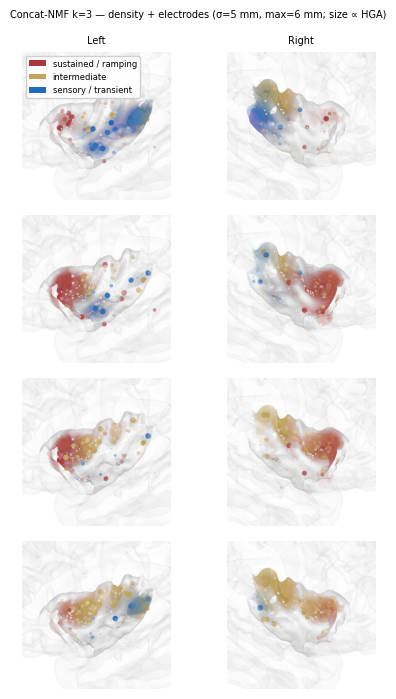

In [ ]:
# Density + electrode overlay (same Gaussian params as previous cell)
SPATIAL_DENSITY_ELEC_OUT = IMG_DIR / 'functional_hga_spatial_phases_density_electrodes.svg'


def render_phase_brains_density_electrodes(
    spatial: pd.DataFrame,
    *,
    bandwidth: float = DENSITY_BANDWIDTH,
    max_distance: float = DENSITY_MAX_DISTANCE,
    weight_by_hga: bool = DENSITY_WEIGHT_BY_HGA,
):
    """Gaussian RGB density underlay + cluster electrode spheres (size ∝ HGA)."""
    all_hga = spatial['HGA'].to_numpy(float)
    vmin = 0.0
    vmax = float(np.percentile(all_hga, 90)) if len(all_hga) else 1.0

    lh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    rh_brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi='rh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            brain = lh_brain if lab.hemi == 'lh' else rh_brain
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.55)

    cord = spatial[['x', 'y', 'z']].to_numpy(float)
    clusters = spatial['functional_cluster'].to_numpy()
    hga_values = spatial['HGA'].to_numpy(float)
    weights = hga_values if weight_by_hga else np.ones(len(spatial), dtype=float)
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    dens_lh = compute_cluster_densities(
        lh_pial_coords, cord[mask_lh], clusters[mask_lh], weights[mask_lh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    dens_rh = compute_cluster_densities(
        rh_pial_coords, cord[mask_rh], clusters[mask_rh], weights[mask_rh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    add_density_rgba_mesh(lh_brain, 'lh', lh_pial_coords, densities_to_rgba(dens_lh))
    add_density_rgba_mesh(rh_brain, 'rh', rh_pial_coords, densities_to_rgba(dens_rh))

    if mask_lh.any():
        add_cluster_electrodes(
            lh_brain, cord[mask_lh], hga_values[mask_lh], clusters[mask_lh],
            lh_tree, lh_pial_coords, vmin, vmax,
        )
    if mask_rh.any():
        add_cluster_electrodes(
            rh_brain, cord[mask_rh], hga_values[mask_rh], clusters[mask_rh],
            rh_tree, rh_pial_coords, vmin, vmax,
        )

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)
    lh_img = lh_brain.screenshot(mode='rgb')
    rh_img = rh_brain.screenshot(mode='rgb')
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img, vmin, vmax


fig, axes = plt.subplots(
    nrows=len(PHASES), ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(0.5, 0.5, f'No data ({phase})', ha='center', va='center')
            axes[row, col].axis('off')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lh_img, rh_img, vmin, vmax = render_phase_brains_density_electrodes(spatial)

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title('Left' if row == 0 else '', fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title('Right' if row == 0 else '', fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])
    for c in CLUSTERS
]
axes[0, 0].legend(
    handles=legend_elements, loc='upper left',
    fontsize=fontsize - 1, framealpha=0.9,
)
fig.suptitle(
    f'Concat-NMF k=3 — density + electrodes '
    f'(σ={DENSITY_BANDWIDTH:g} mm, max={DENSITY_MAX_DISTANCE:g} mm; size ∝ HGA)',
    fontsize=fontsize,
)
fig.tight_layout()
fig.savefig(SPATIAL_DENSITY_ELEC_OUT, dpi=300, bbox_inches='tight')
print(f'Wrote {SPATIAL_DENSITY_ELEC_OUT.resolve()}')
plt.show()


## Optional: Y–Z scatter (lighter spatial check)

No Brain rendering — useful on login nodes.


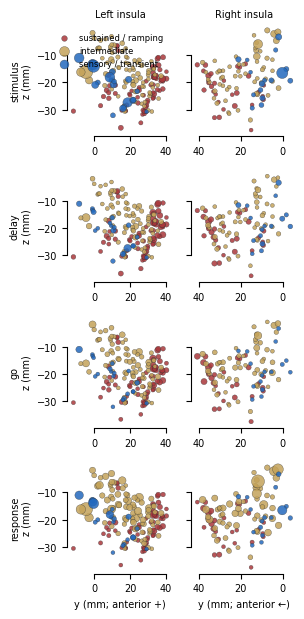

Figures written under /hpc/group/coganlab/nanlinshi/insula-functional/img/functional_hga


In [ ]:
# sharex=False so right hemi can be mirrored (match Brain lateral views:
# left azimuth=180 → anterior to the right; right azimuth=0 → anterior to the left).
fig, axes = plt.subplots(
    nrows=len(PHASES), ncols=2,
    figsize=(8 * cm, 4 * len(PHASES) * cm),
    sharex=False, sharey=True,
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase[phase]
    for col, (hemi, title) in enumerate((('L', 'Left'), ('R', 'Right'))):
        ax = axes[row, col]
        side = spatial[spatial['hemi'] == hemi]
        for cluster in CLUSTERS:
            pts = side[side['functional_cluster'] == cluster]
            sizes = 8 + 40 * np.clip(pts['HGA'].to_numpy(float), 0, None) / 1.5
            ax.scatter(
                pts['y'], pts['z'], s=sizes,
                color=CLUSTER_COLORS[cluster],
                edgecolor='0.2', linewidth=0.25, alpha=0.85,
                label=CLUSTER_LABELS[cluster] if row == 0 and col == 0 else None,
            )
        if hemi == 'R':
            ax.invert_xaxis()
        if row == 0:
            ax.set_title(f'{title} insula', fontsize=fontsize)
        if col == 0:
            ax.set_ylabel(f'{phase}\nz (mm)', fontsize=fontsize)
        if row == len(PHASES) - 1:
            xlabel = 'y (mm; anterior +)' if hemi == 'L' else 'y (mm; anterior ←)'
            ax.set_xlabel(xlabel, fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax, offset=1, trim=True)

axes[0, 0].legend(frameon=False, fontsize=6)
fig.tight_layout()
plt.show()
print(f'Figures written under {IMG_DIR}')


## Supplementary: sentence stimuli

Same NMF functional-cluster framing as the main traces/heatmap/spatial maps above, but HGA is
loaded only from `results/hga/SentenceRep(sentence)` (long epoch window, −1 to 3 s).

Cluster membership still comes from the canonical NMF assignments (word-family
discovery); this panel is for generalization to sentence stimuli, not a re-fit.
Picture naming remains in the main multi-task load above and is not singled out here.

Outputs (do not overwrite main figures):
- `functional_hga_traces_sentence.svg`
- `functional_hga_heatmap_sentence.svg`
- `functional_hga_spatial_phases_sentence.svg`


In [ ]:
# Load sentence-family packaged HGA; reuse NMF channel → cluster map from above.
SENTENCE_TASK = 'SentenceRep(sentence)'
sentence_paths = BIDSPath(
    root=str(hga_results_dir(SENTENCE_TASK)),
    datatype='HGA',
    suffix='time',
    check=False,
).match()

sentence_frames = []
for path in tqdm(sentence_paths, desc='load SentenceRep(sentence) HGA'):
    df = pd.read_csv(path)
    if 'channel' not in df.columns:
        continue
    df = df[df['channel'].isin(keep_channels)]
    if not df.empty:
        sentence_frames.append(df)

if not sentence_frames:
    raise FileNotFoundError(
        f'No HGA rows for NMF channels under results/hga/{SENTENCE_TASK}'
    )

HGAs_sentence = pd.concat(sentence_frames, ignore_index=True)
HGAs_sentence.loc[HGAs_sentence.phase == 'Resp', 'phase'] = 'Response'
HGAs_sentence.loc[HGAs_sentence.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs_sentence['phase'] = HGAs_sentence['phase'].astype(str).str.lower()
HGAs_sentence['functional_cluster'] = HGAs_sentence['channel'].map(assign_map)

subset_sentence = HGAs_sentence[
    (HGAs_sentence.description == DESCRIPTION)
    & (HGAs_sentence.modality == MODALITY)
    & HGAs_sentence['functional_cluster'].isin(CLUSTERS)
    & ~HGAs_sentence['subject'].isin(EXCLUDE_SUBJECTS)
].copy()
subset_sentence['cluster_label'] = subset_sentence['functional_cluster'].map(CLUSTER_LABELS)

print('sentence HGA root:', hga_results_dir(SENTENCE_TASK))
print(subset_sentence.groupby('functional_cluster')['channel'].nunique())
print('phases:', sorted(subset_sentence.phase.unique()))
print(
    'time range:',
    float(subset_sentence.time.min()),
    float(subset_sentence.time.max()),
)
display(subset_sentence.head())


load SentenceRep(sentence) HGA:   0%|          | 0/210 [00:00<?, ?it/s]

sentence HGA root: /hpc/group/coganlab/nanlinshi/insula-functional/results/hga/SentenceRep(sentence)
functional_cluster
intermediate         21
sensory_transient     2
sustained_ramping    13
Name: channel, dtype: int64
phases: ['delay', 'go', 'response', 'stimulus']
time range: -1.0 2.9921875


,time,channel,value,mask,subject,description,task,phase,modality,label,...,x2_template,y2_template,z2_template,contact_1,contact_2,contact_1_label,contact_2_label,mix,functional_cluster,cluster_label
512,-1.000000,D0022_LPIF3-4,0.374811,True,D0022,Repeat,SentenceRep,delay,sound,insula posterior long gyrus L,...,-37.1005,-3.5745,-20.11631,LPIF3,LPIF4,0,insula posterior long gyrus L,False,intermediate,intermediate
513,-0.992188,D0022_LPIF3-4,0.415295,True,D0022,Repeat,SentenceRep,delay,sound,insula posterior long gyrus L,...,-37.1005,-3.5745,-20.11631,LPIF3,LPIF4,0,insula posterior long gyrus L,False,intermediate,intermediate
514,-0.984375,D0022_LPIF3-4,0.506301,True,D0022,Repeat,SentenceRep,delay,sound,insula posterior long gyrus L,...,-37.1005,-3.5745,-20.11631,LPIF3,LPIF4,0,insula posterior long gyrus L,False,intermediate,intermediate
515,-0.976562,D0022_LPIF3-4,0.592239,True,D0022,Repeat,SentenceRep,delay,sound,insula posterior long gyrus L,...,-37.1005,-3.5745,-20.11631,LPIF3,LPIF4,0,insula posterior long gyrus L,False,intermediate,intermediate
516,-0.968750,D0022_LPIF3-4,0.635459,True,D0022,Repeat,SentenceRep,delay,sound,insula posterior long gyrus L,...,-37.1005,-3.5745,-20.11631,LPIF3,LPIF4,0,insula posterior long gyrus L,False,intermediate,intermediate


### S1. Time traces (sentence)


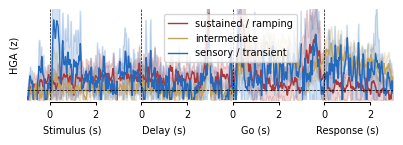

In [ ]:
# Supplementary time traces (sentence-family HGA)
hue_order = [CLUSTER_LABELS[c] for c in CLUSTERS]
palette = [CLUSTER_COLORS[c] for c in CLUSTERS]

fig, axes = plt.subplots(
    nrows=1, ncols=len(PHASES), figsize=(3 * len(PHASES) * cm, 3 * cm),
)
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, PHASES):
    legend = ax is axes[-2]
    sns.lineplot(
        data=subset_sentence[subset_sentence.phase == phase],
        x='time',
        y='value',
        hue='cluster_label',
        hue_order=hue_order,
        ax=ax,
        palette=palette,
        legend=legend,
        lw=1,
    )
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)

    if ax is axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=fontsize)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_ylim(-0.1, 0.8)
    ax.set_ylabel('HGA (z)' if ax is axes[0] else '', fontsize=fontsize)
    ax.set_xlim(-1.0, 3.0)

fig.savefig(IMG_DIR / 'functional_hga_traces_sentence.svg', dpi=300, bbox_inches='tight')
plt.show()


### S2. Heatmap (sentence)


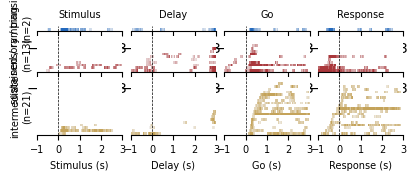

In [ ]:
# Supplementary heatmap (sentence-family HGA; x-axis to ~3 s)
agg_sentence = (
    subset_sentence.groupby(
        ['channel', 'time', 'phase', 'functional_cluster'], as_index=False
    )
    .agg(value=('value', 'mean'), mask=('mask', 'any'))
)
agg_sentence.loc[~agg_sentence['mask'], 'value'] = np.nan

HEATMAP_CLUSTERS = ['sensory_transient', 'sustained_ramping', 'intermediate']
SENTENCE_XTICKS = [-1.0, 0.0, 1.0, 2.0, 3.0]

n_by_cluster = {
    c: int(subset_sentence.loc[subset_sentence.functional_cluster == c, 'channel'].nunique())
    for c in HEATMAP_CLUSTERS
}
height_ratios = [max(n_by_cluster[c], 1) for c in HEATMAP_CLUSTERS]

fig = plt.figure(
    figsize=(3 * len(PHASES) * cm, 0.1 * sum(height_ratios) * cm),
)
gs = fig.add_gridspec(
    nrows=len(HEATMAP_CLUSTERS),
    ncols=len(PHASES),
    height_ratios=height_ratios,
    hspace=0.15,
    wspace=0.1,
)
axes = np.empty((len(HEATMAP_CLUSTERS), len(PHASES)), dtype=object)
for i in range(len(HEATMAP_CLUSTERS)):
    for j in range(len(PHASES)):
        sharex = axes[0, j] if i > 0 else None
        axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

for i, cluster in enumerate(HEATMAP_CLUSTERS):
    cmap = CLUSTER_CMAPS[cluster]
    for j, phase in enumerate(PHASES):
        ax = axes[i, j]
        ordered = cluster_phase_channel_order(agg_sentence, phase, cluster)
        phase_data = agg_sentence[
            (agg_sentence.phase == phase)
            & (agg_sentence.functional_cluster == cluster)
            & agg_sentence.channel.isin(ordered)
        ]

        if not ordered:
            ax.text(
                0.5, 0.5, 'No channels',
                ha='center', va='center', transform=ax.transAxes, fontsize=fontsize,
            )
            ax.set_yticks([])
            continue

        pivot = (
            phase_data.pivot(index='channel', columns='time', values='value')
            .reindex(index=ordered)
        )
        da = xr.DataArray(
            pivot.to_numpy(dtype=float),
            coords={'channel': pivot.index, 'time': pivot.columns.astype(float)},
            dims=['channel', 'time'],
        )
        time_values = da.coords['time'].values.astype(float)
        step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
        time_edges = np.concatenate(
            ([time_values[0] - step / 2],
             time_values[:-1] + step / 2,
             [time_values[-1] + step / 2])
        )
        channel_edges = np.arange(len(ordered) + 1)
        T, C = np.meshgrid(time_edges, channel_edges)

        ax.pcolormesh(
            T, C, da.values, cmap=cmap, vmin=0, vmax=1,
            shading='auto', rasterized=True,
        )
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, len(ordered))
        ax.set_xlim(-1.0, 3.0)
        ax.set_yticks([])
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines['left'].set_visible(False)

        if i == len(HEATMAP_CLUSTERS) - 1:
            ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)
            ax.set_xticks(SENTENCE_XTICKS)
            ax.tick_params(labelsize=fontsize)
        else:
            ax.set_xlabel('')
            ax.set_xticks([])
            plt.setp(ax.get_xticklabels(), visible=False)

        if j == 0:
            ax.set_ylabel(
                f"{CLUSTER_LABELS[cluster]}\n(n={len(ordered)})",
                fontsize=fontsize,
            )
        if i == 0:
            ax.set_title(phase.capitalize(), fontsize=fontsize)

fig.savefig(IMG_DIR / 'functional_hga_heatmap_sentence.svg', dpi=300, bbox_inches='tight')
plt.show()


### S3. Spatial maps (sentence)

Same Brain rendering as §3 above (`render_phase_brains`): electrode spheres sized by
phase-window mean HGA, colored by NMF cluster. Uses `SPATIAL_TIME` post-onset windows.
Requires the main spatial setup cells (surface labels / `render_phase_brains`) to have been run.


In [ ]:
# Supplementary spatial maps (sentence-family HGA)
spatial_by_phase_sentence = {
    phase: phase_spatial_table(subset_sentence, phase) for phase in PHASES
}
for phase, table in spatial_by_phase_sentence.items():
    counts = ', '.join(
        f'{c}={int((table.functional_cluster == c).sum())}' for c in CLUSTERS
    )
    print(f'{phase}: n={len(table)} | {counts}')

fig, axes = plt.subplots(
    nrows=len(PHASES), ncols=2,
    figsize=(12 * cm, 4.5 * len(PHASES) * cm),
)

for row, phase in enumerate(PHASES):
    spatial = spatial_by_phase_sentence[phase]
    if spatial.empty:
        for col in (0, 1):
            axes[row, col].text(0.5, 0.5, f'No data ({phase})', ha='center', va='center')
            axes[row, col].axis('off')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        lh_img, rh_img, vmin, vmax = render_phase_brains(spatial)

    axes[row, 0].imshow(lh_img)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(phase.capitalize(), fontsize=fontsize)
    axes[row, 0].set_title('Left' if row == 0 else '', fontsize=fontsize)

    axes[row, 1].imshow(rh_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title('Right' if row == 0 else '', fontsize=fontsize)

legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[c], label=CLUSTER_LABELS[c])
    for c in CLUSTERS
]
axes[0, 0].legend(
    handles=legend_elements, loc='upper left',
    fontsize=fontsize - 1, framealpha=0.9,
)
fig.suptitle(
    'Sentence stimuli — phase-window HGA (size ∝ amplitude; NMF k=3 clusters)',
    fontsize=fontsize,
)
fig.tight_layout()
out = IMG_DIR / 'functional_hga_spatial_phases_sentence.svg'
fig.savefig(out, dpi=300, bbox_inches='tight')
print(f'Wrote {out.resolve()}')
plt.show()
